# Data-Driven Sales Organisation and Demand Analysis For Retail Business

## Problem Defination 
 - Retail businesses lack data-driven insights to understand sales patterns, customer behavior, and external economic influences, leading to inefficiencies in inventory management and missed revenue opportunities.
 - They fail to make informed decisions about:
    * What Products to stock
    * When demand increases or drops
    * How external factors like (economy, pricing and competition) affect sales
      Most decisions are based on intuition rather than data


## Project Aim
To analyze sales data and external economic factors to uncover patterns, trends, and key drivers of sales performance, and provide actionable insights for better business decision-making.

## Business Objective


- To help businesses improve sales performance
- To help businesses optimize inventory management
- To help businesses identify high-performing products
- To help businesses understand impact of pricing and advertising
- To Support data-driven decision-making

## Key Business Questions

 - Which factors most influence sales performance?
 - How do price and advertising affect sales?
 - Which vehicle types/products perform best?
 - Are there seasonal trends in sales?
 - How does the economic environment (GDP, unemployment) impact sales?
 - Which cities perform best and why?
 - How does competition affect sales?


## Importance of the Analysis
 - This analysis demonstrates how businesses can move from intuition-based decisions to data-driven strategies, improving efficiency, profitability, and customer satisfaction.

## Dataset Description

The dataset contains historical automobile sales information across different years, months, vehicle types, and regions during recession and non-recession periods. <br>

Source: IBM skills <br>
Formart: CSV file
URL: ("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv")

The dataset includes the following variables:
1. *Date*: The month end date of sales observation.
2.**Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
3. *Automobile_Sales*: The number of vehicles sold during the period.
4. *GDP*: The per capita GDP value in USD.
5. *Unemployment_Rate*: The monthly unemployment rate.
6. *Consumer_Confidence*: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
7. *Seasonality_Weight*: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods. A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches). A value less than 1 suggests lower-than-average sales due to seasonal slowdowns. A value around 1 means the season has neutral or average effect on sales.
8. *Price*: The average vehicle price during the period.
9. *Advertising_Expenditure*: The advertising expenditure of the company.
10. *Vehicle_Type*: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.
11. *Competition*: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
12. *Month*: Month of the observation extracted from Date..
13. *Year*: Year of the observation extracted from Date.
By examining various factors mentioned above from the dataset, you aim to gain insights into how recessions impacted automobile sales for your company. storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv" <br>

## Import Required Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load the Dataset for our use 
We are going toload the dataset from the file Path url though its still in the file folder 

In [4]:
FILE_PATH = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
df= pd.read_csv(FILE_PATH)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [5]:
df.shape

(2112, 15)

In [6]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [7]:
df.columns=df.columns.str.lower()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     2112 non-null   object 
 1   year                     2112 non-null   int64  
 2   month                    2112 non-null   object 
 3   recession                2112 non-null   int64  
 4   consumer_confidence      2112 non-null   float64
 5   seasonality_weight       2112 non-null   float64
 6   price                    2112 non-null   int64  
 7   advertising_expenditure  2112 non-null   float64
 8   competition              2112 non-null   int64  
 9   gdp                      2112 non-null   float64
 10  growth_rate              2112 non-null   float64
 11  unemployment_rate        2112 non-null   float64
 12  automobile_sales         2112 non-null   float64
 13  vehicle_type             2112 non-null   object 
 14  city                    

In [11]:
df.describe()

,year,recession,consumer_confidence,seasonality_weight,price,advertising_expenditure,competition,gdp,growth_rate,unemployment_rate,automobile_sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [9]:
df['date']=pd.to_datetime(df['date'])

In [10]:
df.dtypes

date                       datetime64[ns]
year                                int64
month                              object
recession                           int64
consumer_confidence               float64
seasonality_weight                float64
price                               int64
advertising_expenditure           float64
competition                         int64
gdp                               float64
growth_rate                       float64
unemployment_rate                 float64
automobile_sales                  float64
vehicle_type                       object
city                               object
dtype: object

In [13]:
str_df= df.loc[:,['month', 'vehicle_type', 'city']]
str_df.head()

,month,vehicle_type,city
0,Jan,SmallFamilyCar,Georgia
1,Jan,Sports,Georgia
2,Jan,SuperMiniCar,Georgia
3,Jan,MediumFamilyCar,Georgia
4,Feb,SmallFamilyCar,New York


In [14]:
for col in str_df.columns:
    df[col] = df[col].str.lower()

In [15]:
df.head()

,date,year,month,recession,consumer_confidence,seasonality_weight,price,advertising_expenditure,competition,gdp,growth_rate,unemployment_rate,automobile_sales,vehicle_type,city
0,1980-01-31,1980,jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,smallfamilycar,georgia
1,1980-01-31,1980,jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,sports,georgia
2,1980-01-31,1980,jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,superminicar,georgia
3,1980-01-31,1980,jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,mediumfamilycar,georgia
4,1980-02-29,1980,feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,smallfamilycar,new york


## Key Questions to solve: Begin of Analysis

### Q1. How did the Automobile sales perform over the years
- Here we will investigate the trends of automobile sales in the entire years for both recession and non recession years and the general performance to track the trent. 

In [16]:
automob_sales= (df.groupby('year')['automobile_sales'].sum().reset_index())

In [17]:
automob_sales.head()

,year,automobile_sales
0,1980,25960.90
1,1981,23614.32
2,1982,37313.00
3,1983,213163.00
4,1984,188863.00


In [18]:
automob_sales.tail()

,year,automobile_sales
39,2019,194443.00
40,2020,138760.00
41,2021,186847.84
42,2022,122601.00
43,2023,154482.00


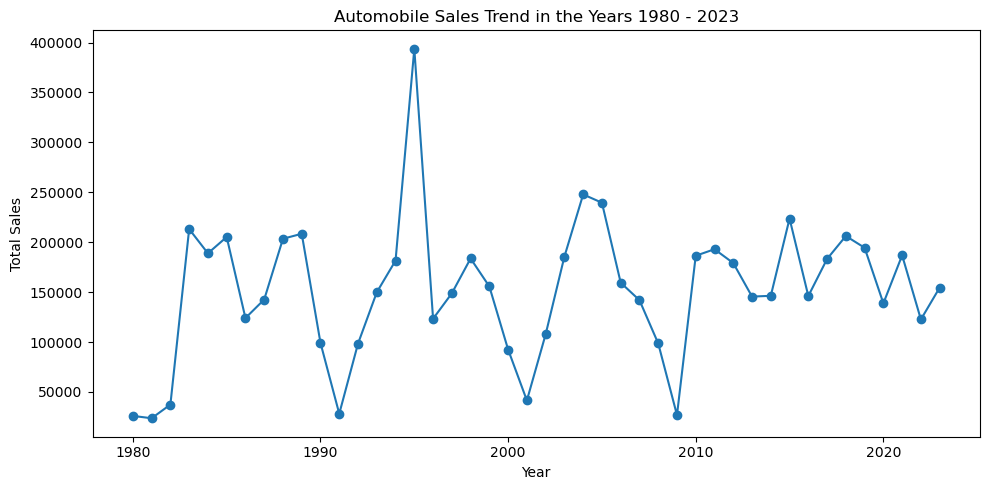

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    'year',
    'automobile_sales',
    data=automob_sales,
    marker='o'
)
plt.title('Automobile Sales Trend in the Years 1980 - 2023')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [29]:
print(automob_sales['automobile_sales'].max())
print(automob_sales['automobile_sales'].min())

393772.0
23614.32


**Insight**
- The sales trend shows some yearly flactuations with some years showing high sales output with the trend line reading a very high point like the year 1995 sales seems to have reahed the maximum showing a highest sales at 393772 and the lowest sale being 23614 showing that some properties affect tatal sales output there by the flactuations in the overall dales

In [31]:
df.to_csv('cleaned_automobilesales.csv', index=False)

**We will now regroup the data into recession and non recession to see how the sales performed in the different periods of economic impact**

In [41]:
auto_sales=(df.groupby(['year', 'recession'])['automobile_sales'].sum().reset_index())

In [48]:
auto_sales.head(40)

,year,recession,automobile_sales
0,1980,1,25960.90
1,1981,1,23614.32
2,1982,1,37313.00
3,1983,0,213163.00
4,1984,0,188863.00
5,1985,0,205234.00
6,1986,0,123990.00
7,1987,0,142581.00
8,1988,0,203459.00
9,1989,0,208446.00


In [42]:
recession_sales=auto_sales[auto_sales['recession']==1]
non_recession_sales=auto_sales[auto_sales['recession']==0]

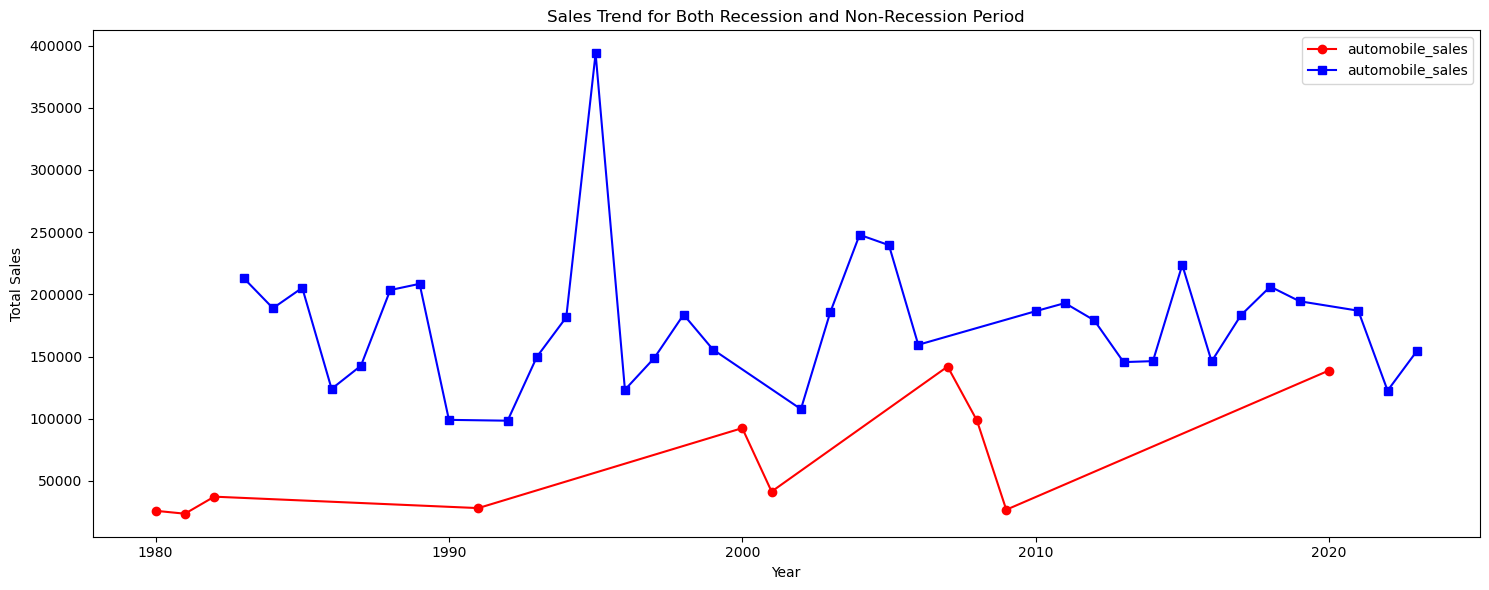

In [44]:
plt.figure(figsize=(15, 6))

plt.plot(
    'year',
    'automobile_sales',
    data=recession_sales,
    marker='o',
    color='red'
)
plt.plot(
    'year',
    'automobile_sales',
    data=non_recession_sales,
    marker='s',
    color='blue'

)

plt.title('Sales Trend for Both Recession and Non-Recession Period')

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.legend()

plt.show()